In [2]:
import numpy as np
import pandas as pd

np.random.seed(23) 

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)

In [3]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


plotly.express (px) is a high-level visualization library in Python used to create interactive graphs with very little code.

    📊 Matplotlib = manual drawing
✨ Plotly Express = smart automatic plotting

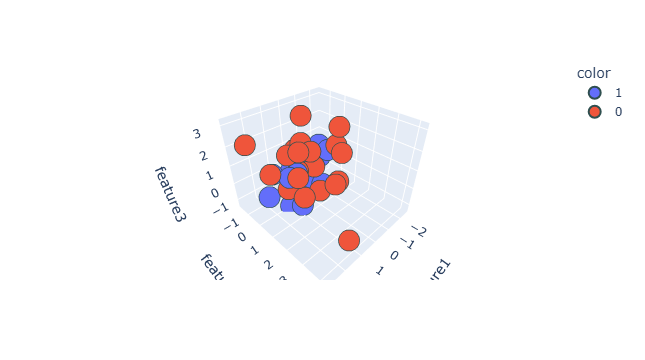

In [4]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()
     

In [5]:
# Step 1 - Apply standard scaling -->mean centering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])
     

In [6]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [7]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [8]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [9]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

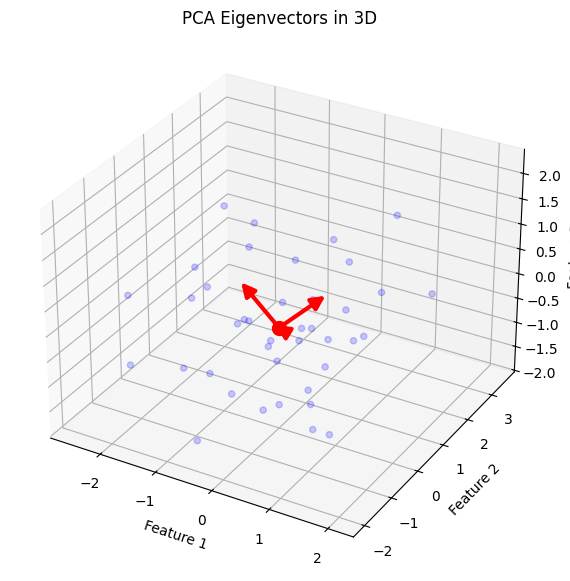

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# -------------------------
# STEP 1: Create Dataset
# -------------------------
np.random.seed(23)

mu_vec1 = np.array([0, 0, 0])
mu_vec2 = np.array([1, 1, 1])
cov_mat = np.eye(3) #Creates an Identity Matrix of size n × n.

class1 = np.random.multivariate_normal(mu_vec1, cov_mat, 20)
class2 = np.random.multivariate_normal(mu_vec2, cov_mat, 20)

df = pd.DataFrame(np.vstack((class1, class2)),
                  columns=['feature1', 'feature2', 'feature3'])

# -------------------------
# STEP 2: PCA Computation
# -------------------------
X_scaled = StandardScaler().fit_transform(df)
pca = PCA(n_components=3)
pca.fit(X_scaled)

eigen_vectors = pca.components_
mean_point = X_scaled.mean(axis=0)

# -------------------------
# STEP 3: 3D Arrow Class (FIXED)
# -------------------------
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.get_proj())
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        _, _, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.get_proj())
        return np.min(zs)


# -------------------------
# STEP 4: Plot
# -------------------------
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot data points
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2],
           color='blue', alpha=0.2)

# Plot mean
ax.scatter(mean_point[0], mean_point[1], mean_point[2],
           color='red', s=100)

# Plot eigenvectors
for v in eigen_vectors:
    arrow = Arrow3D([mean_point[0], mean_point[0] + v[0]],
                    [mean_point[1], mean_point[1] + v[1]],
                    [mean_point[2], mean_point[2] + v[2]],
                    mutation_scale=20, lw=3, arrowstyle="-|>", color="r")
    ax.add_artist(arrow)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
plt.title('PCA Eigenvectors in 3D')
plt.show()


In [14]:
pc = eigen_vectors[0:2]
pc

array([[ 0.53875915,  0.65608325,  0.52848211],
       [-0.69363291, -0.01057596,  0.72025103]])

In [17]:
df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])
df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)
df = df.sample(40, random_state=42)


In [18]:
X = df[['feature1','feature2','feature3']].values
y = df['target'].values   # store target safely

# Center data
X_centered = X - X.mean(axis=0)

# PCA transform
transformed_df = np.dot(X_centered, pc.T)

# New dataframe
new_df = pd.DataFrame(transformed_df, columns=['PC1','PC2'])
new_df['target'] = y

new_df.head()


,PC1,PC2,target
0,-0.899290,1.373845,1
1,-1.541722,0.035355,1
2,-0.280107,-0.222394,1
3,0.315346,-0.211995,0
4,-1.227068,-1.150896,1


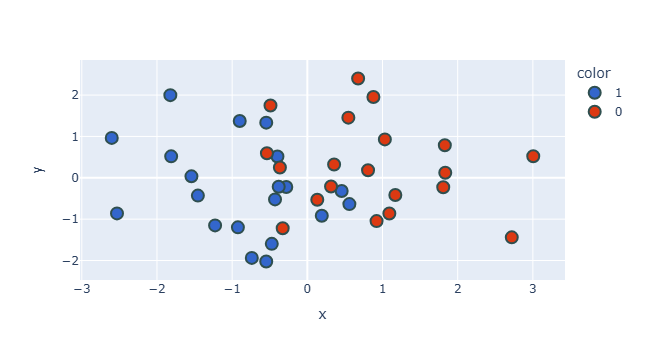

In [19]:

new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()